# Model Review

This notebook can lookvthrough all your models stored locally and provide some information on each of them. This can be handy if you're trying to find a specific part of your training process.

In [18]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import os
import yaml

from deepracer.tracks import TrackIO, Track
from deepracer.tracks.track_utils import track_breakdown, track_meta
from deepracer.logs import \
    SimulationLogsIO as slio, \
    NewRewardUtils as nr, \
    AnalysisUtils as au, \
    PlottingUtils as pu, \
    ActionBreakdownUtils as abu, \
    DeepRacerLog, \
    S3FileHandler, FSFileHandler

# Ignore deprecation warnings we have no power over
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Load Location of MinIO Bucket
BUCKET='bucket'       # Bucket name is default 'bucket' when training locally
PROFILE='minio'          # The credentials profile in .aws - 'minio' for local training

## if you are using this notebook in windows and looking for the IP address to access WSL use the command 
# $hostname -I
# If running this notebook within WSL you can use 'http://minio:9000'
S3_ENDPOINT_URL='http://172.29.159.154:9000'
# If you want to pull files from your bucket folder type the address aboove into your browser and change "9000" to "9001"
# e.g. (http://172.22.79.106:9001)
# look up the docker container named minio... and "inspect"  it to find the credentials to log in.
# $ docker inspect <container_id> | grep -i "minio" -A 10

### List all models that you have locally
Enter the path to your minio bucket in WSL below

In [26]:
# List all Folders in the MinIO bucket
# give the path to the local MinIO bucket
# Be sure to use the double backslashes in the path to avoid issues with escape characters
bucket_path = '\\\\wsl.localhost\\Ubuntu\\home\\spencer\\deepracer-for-cloud\\data\\minio\\bucket'
bucket_contents = os.listdir(bucket_path)
bucket_contents.sort()
bucket_contents.remove('custom_files')  # Remove the 'custom_files' folder from the list
for folder in bucket_contents:
    fh = S3FileHandler(bucket=BUCKET, prefix=folder, profile=PROFILE, s3_endpoint_url=S3_ENDPOINT_URL)
    if '{folder}/training_params.yaml' in fh.list_files():
        training_paramas = fh.get_file(folder + '/training_params.yaml')
        yaml_params = yaml.safe_load(training_paramas)
        training_track = yaml_params['WORLD_NAME']
        print(folder)
        print(f'Track: {training_track}')
        print('---'*10)

# Load track information
tu = TrackIO('C:\\Users\\spenc\\Documents\\Local_Deepracer_Analysis\\tracks')

PREFIX = folder

    

### Filter the models youre looking for
If you want an inclusive or exclusive filter for your model names enter it below

In [20]:
# Model name filters
include_paths_with = ['2026_03_13']  # Only include paths that contain these strings
exclude_paths_with = []  # Exclude paths that contain these strings
track_filters = []  # Only include tracks that contain these strings

Loading data for 2026_03_13_1...
Track: reInvent2019_wide
Loaded 112 waypoints


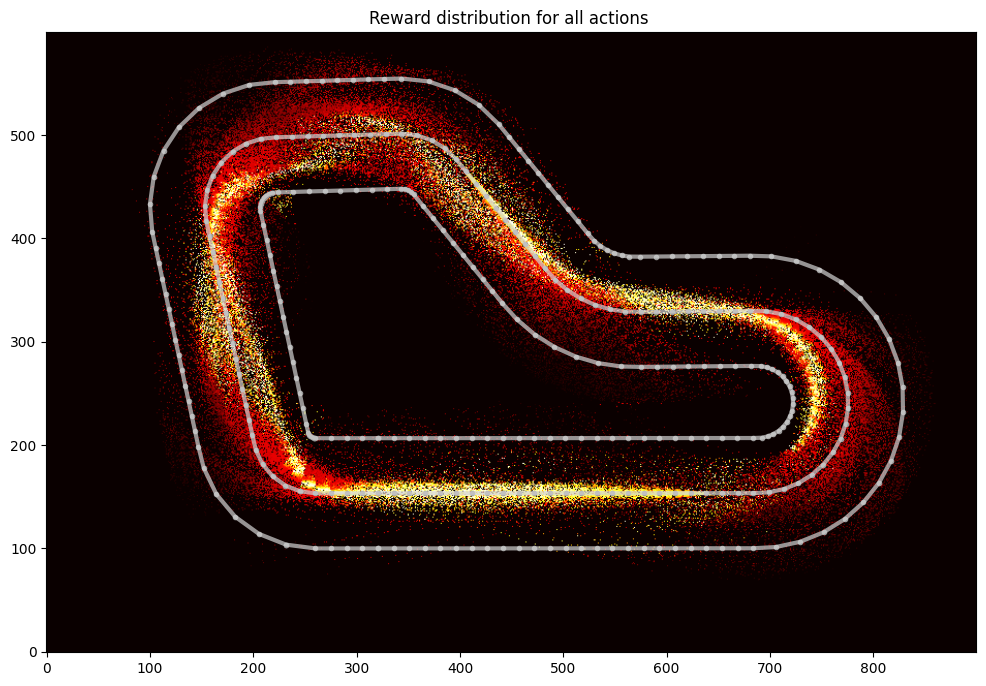

new reward not found, using reward as its values
Multiple workers have been detected, reloading data with grouping by unique_episode
Grouping by 'unique_episode'
Number of episodes =  2099
Number of iterations =  104


<Figure size 640x480 with 0 Axes>

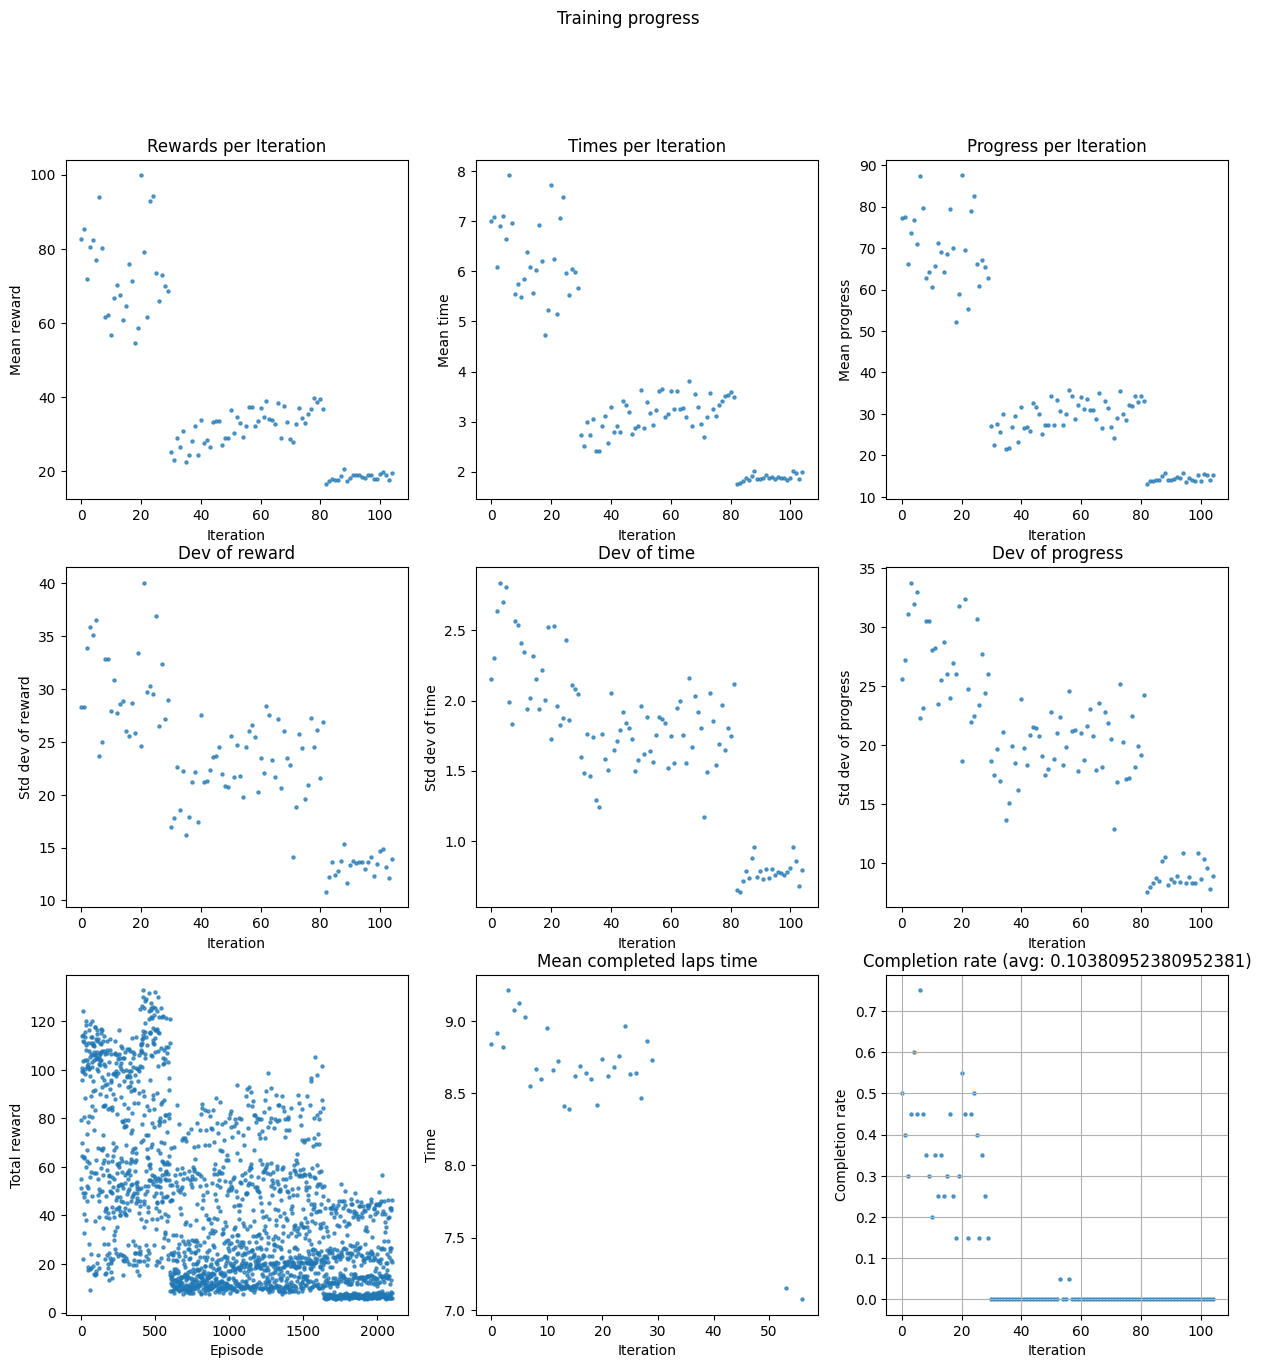

Loading data for 2026_03_13_2...
Track: reInvent2019_wide
Loaded 112 waypoints


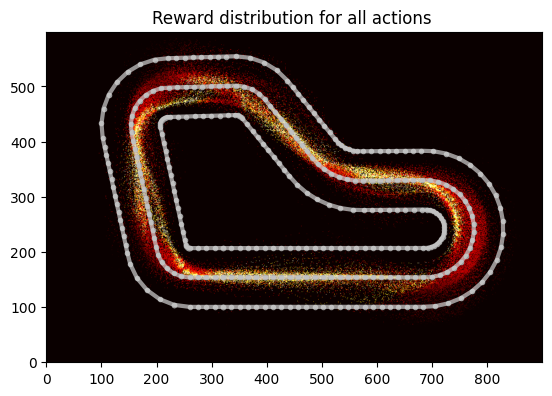

new reward not found, using reward as its values
Multiple workers have been detected, reloading data with grouping by unique_episode
Grouping by 'unique_episode'
Number of episodes =  799
Number of iterations =  39


<Figure size 640x480 with 0 Axes>

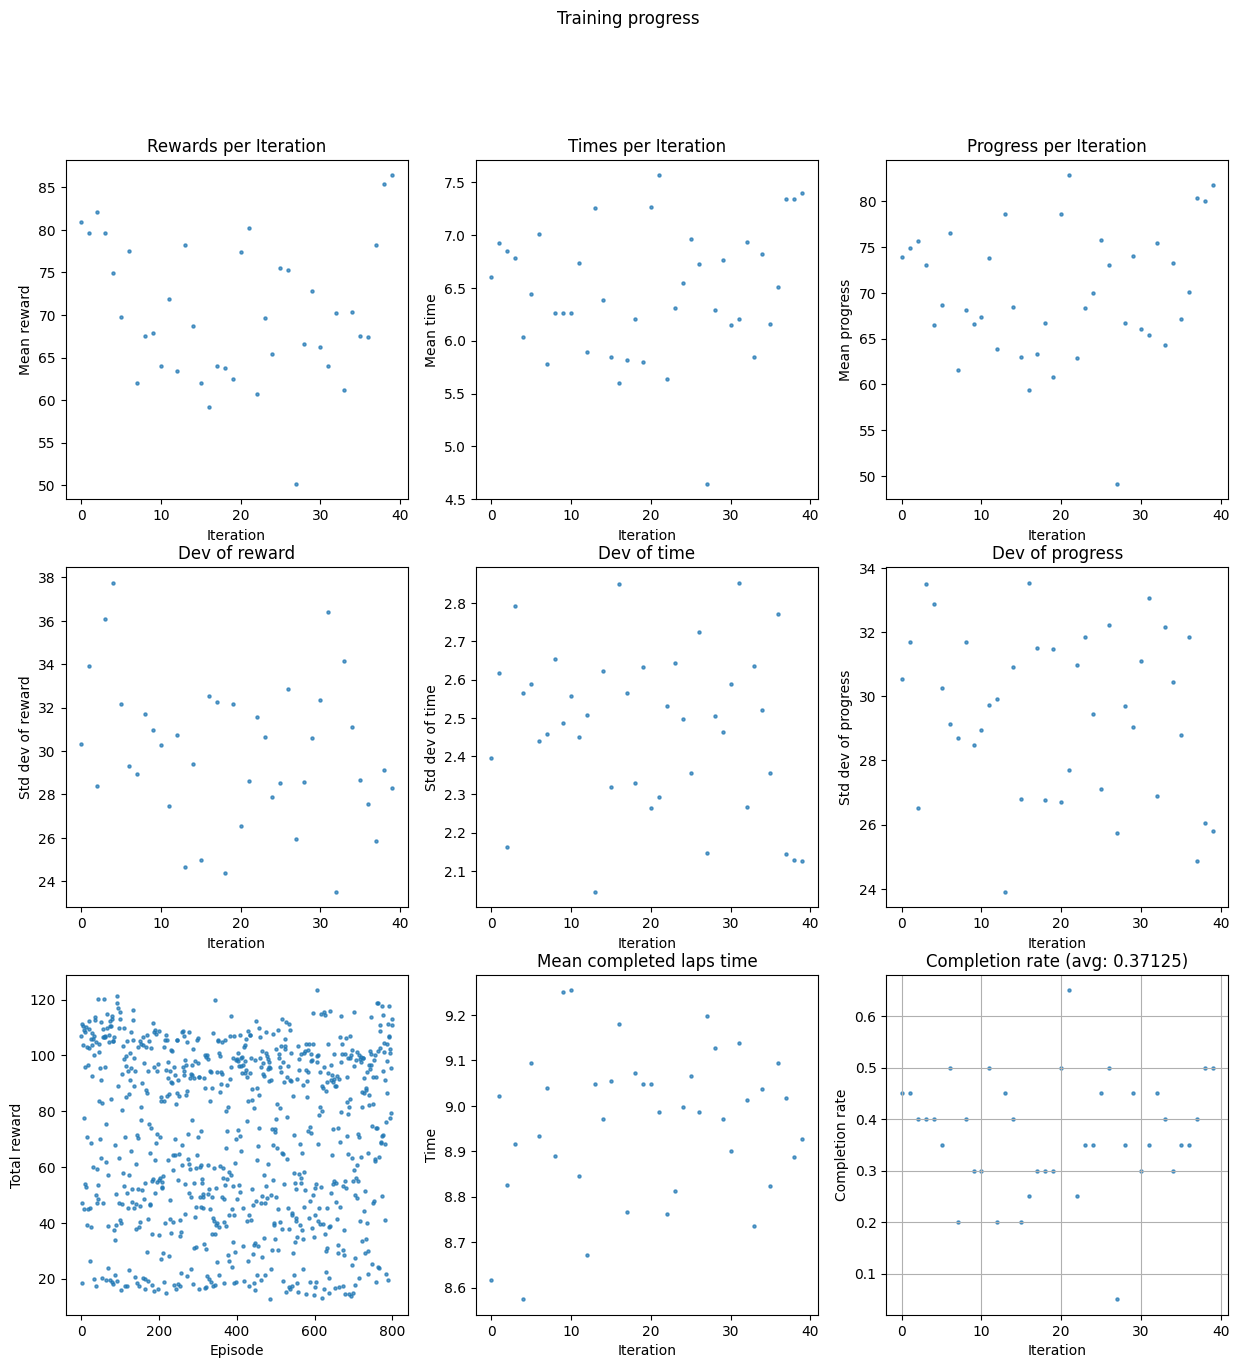

<Figure size 640x480 with 0 Axes>

In [ ]:


def filter_paths(paths, include_filters=None, exclude_filters=None):
    if include_filters is None:
        include_filters = []
    if exclude_filters is None:
        exclude_filters = []
    exclude_filters.append('custom_files')  # Always exclude 'custom_files'
    
    filtered_paths = []
    for path in paths:
        if all(inc in path for inc in include_filters) and not any(exc in path for exc in exclude_filters):
            filtered_paths.append(path)
    return filtered_paths

# Filter the bucket contents based on the include and exclude criteria
filtered_bucket = filter_paths(bucket_contents, include_paths_with, exclude_paths_with)

for folder in filtered_bucket:
    if not track_filters or training_track in track_filters:
        # Load Model Object
        PREFIX = folder
        fh = S3FileHandler(bucket=BUCKET, prefix=PREFIX, profile=PROFILE, s3_endpoint_url=S3_ENDPOINT_URL)
        log = DeepRacerLog(filehandler=fh)
        print(f'Loading data for {PREFIX}...')
        training_paramas = fh.get_file(PREFIX + '/training_params.yaml')

        # Load Dataframe and Track
        yaml_params = yaml.safe_load(training_paramas)
        training_track = yaml_params['WORLD_NAME']
        print(f'Track: {training_track}')
        track: Track = tu.load_track(training_track)
        log.load_training_trace()
        df = log.dataframe()

        # Show heatmap of reward on track
        pu.plot_track(df, track)

        # Show basic training data
        simulation_agg = au.simulation_agg(df)
        try: 
            if df.nunique(axis=0)['worker'] > 1:
                print("Multiple workers have been detected, reloading data with grouping by unique_episode")
                simulation_agg = au.simulation_agg(df, secondgroup="unique_episode")
        except:
            print("Multiple workers not detected, assuming 1 worker")
        au.analyze_training_progress(simulation_agg, title='Training progress')

        



